# Cleaning, fixing, preparing the dataset

In [71]:
# 1. Clone the repository
!git clone https://github.com/felipevalencla/beyond-qualifying-position-formula-one.git

# 2. Read the files from the local directory
import pandas as pd

df_qualifying = pd.read_parquet('beyond-qualifying-position-formula-one/qualifying_results.parquet')
df_race = pd.read_parquet('beyond-qualifying-position-formula-one/race_results.parquet')

fatal: destination path 'beyond-qualifying-position-formula-one' already exists and is not an empty directory.


In [72]:
print(df_race.shape)
print(df_qualifying.shape)

(3458, 10)
(3455, 12)


### Merge the datasets
df_race as the base (left join) and df_qualifying_clean

In [73]:
df_merged = pd.merge(df_race, df_qualifying, on=['season', 'round', 'DriverId', 'TeamId'], how='left')

print(f"Shape of the new merged DataFrame: {df_merged.shape}")
display(df_merged.head())

Shape of the new merged DataFrame: (3458, 18)


,season,round,DriverId,TeamId,grid_position,race_finishing_position,classified_position,status,raw_points,laps_completed,event_name,location,event_date,event_format,qualifying_position,Q1,Q2,Q3
0,2018,1,vettel,ferrari,3,1,1,Finished,25.0,58,Australian Grand Prix,Melbourne,2018-03-25,conventional,3,0 days 00:01:23.348000,0 days 00:01:21.944000,0 days 00:01:21.838000
1,2018,1,hamilton,mercedes,1,2,2,Finished,18.0,58,Australian Grand Prix,Melbourne,2018-03-25,conventional,1,0 days 00:01:22.824000,0 days 00:01:22.051000,0 days 00:01:21.164000
2,2018,1,raikkonen,ferrari,2,3,3,Finished,15.0,58,Australian Grand Prix,Melbourne,2018-03-25,conventional,2,0 days 00:01:23.096000,0 days 00:01:22.507000,0 days 00:01:21.828000
3,2018,1,ricciardo,red_bull,8,4,4,Finished,12.0,58,Australian Grand Prix,Melbourne,2018-03-25,conventional,5,0 days 00:01:23.494000,0 days 00:01:22.897000,0 days 00:01:22.152000
4,2018,1,alonso,mclaren,10,5,5,Finished,10.0,58,Australian Grand Prix,Melbourne,2018-03-25,conventional,11,0 days 00:01:23.597000,0 days 00:01:23.692000,NaT


### Cleaning & Fixing Process

1. Exclude event_format != "conventional"


In [74]:
df_merged_clean = df_merged[df_merged['event_format'] == 'conventional']
print(f"New shape of df_qualifying after filtering: {df_merged_clean.shape}")
display(df_merged_clean.head())

New shape of df_qualifying after filtering: (2975, 18)


,season,round,DriverId,TeamId,grid_position,race_finishing_position,classified_position,status,raw_points,laps_completed,event_name,location,event_date,event_format,qualifying_position,Q1,Q2,Q3
0,2018,1,vettel,ferrari,3,1,1,Finished,25.0,58,Australian Grand Prix,Melbourne,2018-03-25,conventional,3,0 days 00:01:23.348000,0 days 00:01:21.944000,0 days 00:01:21.838000
1,2018,1,hamilton,mercedes,1,2,2,Finished,18.0,58,Australian Grand Prix,Melbourne,2018-03-25,conventional,1,0 days 00:01:22.824000,0 days 00:01:22.051000,0 days 00:01:21.164000
2,2018,1,raikkonen,ferrari,2,3,3,Finished,15.0,58,Australian Grand Prix,Melbourne,2018-03-25,conventional,2,0 days 00:01:23.096000,0 days 00:01:22.507000,0 days 00:01:21.828000
3,2018,1,ricciardo,red_bull,8,4,4,Finished,12.0,58,Australian Grand Prix,Melbourne,2018-03-25,conventional,5,0 days 00:01:23.494000,0 days 00:01:22.897000,0 days 00:01:22.152000
4,2018,1,alonso,mclaren,10,5,5,Finished,10.0,58,Australian Grand Prix,Melbourne,2018-03-25,conventional,11,0 days 00:01:23.597000,0 days 00:01:23.692000,NaT


2. Exclude drivers whose status is clearly 'Did not start'

In [75]:
df_merged_clean = df_merged_clean[df_merged_clean['status'] != 'Did not start']

print(f"Shape of df_merged after excluding 'Did not start' statuses: {df_merged_clean.shape}")
display(df_merged_clean.head())

Shape of df_merged after excluding 'Did not start' statuses: (2970, 18)


,season,round,DriverId,TeamId,grid_position,race_finishing_position,classified_position,status,raw_points,laps_completed,event_name,location,event_date,event_format,qualifying_position,Q1,Q2,Q3
0,2018,1,vettel,ferrari,3,1,1,Finished,25.0,58,Australian Grand Prix,Melbourne,2018-03-25,conventional,3,0 days 00:01:23.348000,0 days 00:01:21.944000,0 days 00:01:21.838000
1,2018,1,hamilton,mercedes,1,2,2,Finished,18.0,58,Australian Grand Prix,Melbourne,2018-03-25,conventional,1,0 days 00:01:22.824000,0 days 00:01:22.051000,0 days 00:01:21.164000
2,2018,1,raikkonen,ferrari,2,3,3,Finished,15.0,58,Australian Grand Prix,Melbourne,2018-03-25,conventional,2,0 days 00:01:23.096000,0 days 00:01:22.507000,0 days 00:01:21.828000
3,2018,1,ricciardo,red_bull,8,4,4,Finished,12.0,58,Australian Grand Prix,Melbourne,2018-03-25,conventional,5,0 days 00:01:23.494000,0 days 00:01:22.897000,0 days 00:01:22.152000
4,2018,1,alonso,mclaren,10,5,5,Finished,10.0,58,Australian Grand Prix,Melbourne,2018-03-25,conventional,11,0 days 00:01:23.597000,0 days 00:01:23.692000,NaT


3. To have a consistent scoring rules across the whole sample, I have implemented FIA's 2025 points structure, this because they abolish the fastest lap bonus point. This ensures that points measure race classification only.

In [76]:
import numpy as np

conditions = [
    (df_merged_clean['race_finishing_position'] == 1),
    (df_merged_clean['race_finishing_position'] == 2),
    (df_merged_clean['race_finishing_position'] == 3),
    (df_merged_clean['race_finishing_position'] == 4),
    (df_merged_clean['race_finishing_position'] == 5),
    (df_merged_clean['race_finishing_position'] == 6),
    (df_merged_clean['race_finishing_position'] == 7),
    (df_merged_clean['race_finishing_position'] == 8),
    (df_merged_clean['race_finishing_position'] == 9),
    (df_merged_clean['race_finishing_position'] == 10)
]

choices = [25, 18, 15, 12, 10, 8, 6, 4, 2, 1]

df_merged_clean['classification_points'] = np.select(conditions, choices, default=0)

print("DataFrame with new 'classification_points' column:")
display(df_merged_clean[['race_finishing_position', 'classification_points']].head(15))

DataFrame with new 'classification_points' column:


,race_finishing_position,classification_points
0,1,25
1,2,18
2,3,15
3,4,12
4,5,10
5,6,8
6,7,6
7,8,4
8,9,2
9,10,1


## Create the targets

1. Top 10
2. Podium
3. IncidentDNF ('Accident', 'Collision', 'Spun off', 'Collision Damage')

In [77]:
# Target 1: Top 10
df_merged_clean['Top10'] = (df_merged_clean['race_finishing_position'] <= 10).astype(int)

# Target 2: Podium
df_merged_clean['Podium'] = (df_merged_clean['race_finishing_position'] <= 3).astype(int)

# Target 3: Incident-related DNF
incident_keywords = ['Accident', 'Collision', 'Spun off']
df_merged_clean['IncidentDNF'] = df_merged_clean['status'].apply(lambda x: 1 if any(keyword in str(x) for keyword in incident_keywords) else 0)

print("DataFrame with new target variables:")
display(df_merged_clean[['race_finishing_position', 'status', 'Top10', 'Podium', 'IncidentDNF']].head())

DataFrame with new target variables:


,race_finishing_position,status,Top10,Podium,IncidentDNF
0,1,Finished,1,1,0
1,2,Finished,1,1,0
2,3,Finished,1,1,0
3,4,Finished,1,0,0
4,5,Finished,1,0,0


### Creating Conventional Baseline Features

To create rolling features based on previous races, we first need to sort the DataFrame by `DriverId`, `season`, and `round` to ensure the correct chronological order. Then, we can use an expanding window for cumulative calculations and shift them by one to exclude the current race's data.

These features capture a driver's recent performance based on their last few races, excluding the current race.

In [78]:
import numpy as np
# Sort the DataFrame to ensure correct chronological order for rolling calculations
df_merged_clean.sort_values(by=['DriverId', 'season', 'round'], inplace=True)

# Driver-specific rolling features

# driver_points_mean_last3: Rolling mean of classification_points over the last 3 races
# Using .transform() to apply rolling and shift within each DriverId group
df_merged_clean['driver_points_mean_last3'] = df_merged_clean.groupby('DriverId')['classification_points'].transform(
    lambda x: x.rolling(window=3, min_periods=1).mean().shift(1)
)

# driver_qualifying_mean_last3: Rolling mean of qualifying_position over the last 3 races
df_merged_clean['driver_qualifying_mean_last3'] = df_merged_clean.groupby('DriverId')['qualifying_position'].transform(
    lambda x: x.rolling(window=3, min_periods=1).mean().shift(1)
)

# driver_incident_rate_last10: Rolling incident rate (sum of IncidentDNF / count of races) over the last 10 races
# Using .transform() for both sum and count within each DriverId group
rolling_incident_sum = df_merged_clean.groupby('DriverId')['IncidentDNF'].transform(
    lambda x: x.rolling(window=10, min_periods=1).sum().shift(1)
)
rolling_race_count = df_merged_clean.groupby('DriverId')['IncidentDNF'].transform(
    lambda x: x.rolling(window=10, min_periods=1).count().shift(1)
)
df_merged_clean['driver_incident_rate_last10'] = rolling_incident_sum / rolling_race_count

# driver_previous_starts: Cumulative count of previous starts for each driver across their career
# This counts the number of races a driver has participated in *before* the current one in their career.
# Will be NaN for the very first race of a driver's career, then 1, 2, 3... for subsequent races.
# Calculate cumulative count of races for each driver (0-indexed)
driver_cum_counts = df_merged_clean.groupby('DriverId').cumcount()

# Shift these counts by 1 within each driver group to get previous races
# This will make the first entry for each driver NaN, then 0, 1, 2...
previous_race_indices = driver_cum_counts.groupby(df_merged_clean['DriverId']).shift(1)

# Add 1 to make it 1-indexed (1, 2, 3... for previous starts)
df_merged_clean['driver_previous_starts'] = previous_race_indices + 1

print("DataFrame with new driver-specific rolling features:")
display(df_merged_clean[['DriverId', 'season', 'round', 'classification_points', 'driver_points_mean_last3', 'qualifying_position', 'driver_qualifying_mean_last3', 'IncidentDNF', 'driver_incident_rate_last10', 'driver_previous_starts']].head())

DataFrame with new driver-specific rolling features:


,DriverId,season,round,classification_points,driver_points_mean_last3,qualifying_position,driver_qualifying_mean_last3,IncidentDNF,driver_incident_rate_last10,driver_previous_starts
1155,aitken,2020,16,0,NaN,18,NaN,0,NaN,NaN
433,albon,2019,1,0,NaN,13,NaN,0,NaN,NaN
448,albon,2019,2,2,0.000000,12,13.000000,0,0.0,1.0
490,albon,2019,4,0,1.000000,12,12.500000,0,0.0,2.0
510,albon,2019,5,0,0.666667,12,12.333333,0,0.0,3.0


### Creating Team-Specific Rolling Features

These features capture a team's recent performance. First, we'll calculate the average performance of a team's drivers per race. Then, we'll compute rolling means of these team-level averages over the last few races.

In [79]:
# Calculate mean classification points per entered driver for each team-race
team_race_agg_points = df_merged_clean.groupby(['season', 'round', 'TeamId'])['classification_points'].mean().reset_index()
team_race_agg_points.rename(columns={'classification_points': 'mean_team_classification_points_per_race'}, inplace=True)
df_merged_clean = pd.merge(df_merged_clean, team_race_agg_points, on=['season', 'round', 'TeamId'], how='left')

# Calculate mean qualifying position per entered driver for each team-race
team_race_agg_qualifying = df_merged_clean.groupby(['season', 'round', 'TeamId'])['qualifying_position'].mean().reset_index()
team_race_agg_qualifying.rename(columns={'qualifying_position': 'mean_team_qualifying_position_per_race'}, inplace=True)
df_merged_clean = pd.merge(df_merged_clean, team_race_agg_qualifying, on=['season', 'round', 'TeamId'], how='left')

print("DataFrame with new team-race aggregate features:")
display(df_merged_clean[['season', 'round', 'TeamId', 'DriverId', 'classification_points', 'mean_team_classification_points_per_race', 'qualifying_position', 'mean_team_qualifying_position_per_race']].head())

DataFrame with new team-race aggregate features:


,season,round,TeamId,DriverId,classification_points,mean_team_classification_points_per_race,qualifying_position,mean_team_qualifying_position_per_race
0,2020,16,williams,aitken,0,0.0,18,17.5
1,2019,1,toro_rosso,albon,0,0.5,13,14.0
2,2019,2,toro_rosso,albon,2,1.0,12,13.5
3,2019,4,toro_rosso,albon,0,0.0,12,9.0
4,2019,5,toro_rosso,albon,0,1.0,12,10.5


In [80]:
import pandas as pd

# Now, calculate rolling team features

# 1. Create a temporary DataFrame with unique team-race data
# This ensures that when we calculate the rolling mean, each unique team-race event is counted only once.
team_race_features = df_merged_clean[['TeamId', 'season', 'round', 'mean_team_classification_points_per_race', 'mean_team_qualifying_position_per_race']].drop_duplicates()

# 2. Sort this temporary DataFrame to ensure correct chronological order for rolling calculations
team_race_features.sort_values(by=['TeamId', 'season', 'round'], inplace=True)

# 3. Calculate rolling features on the temporary DataFrame
team_race_features['calculated_team_points_mean_last3'] = team_race_features.groupby('TeamId')['mean_team_classification_points_per_race'].transform(
    lambda x: x.rolling(window=3, min_periods=1).mean().shift(1)
)
team_race_features['calculated_team_qualifying_mean_last3'] = team_race_features.groupby('TeamId')['mean_team_qualifying_position_per_race'].transform(
    lambda x: x.rolling(window=3, min_periods=1).mean().shift(1)
)

# 4. Merge these new calculated features back to the original df_merged_clean
# This will assign the correct rolling mean to all rows belonging to the same TeamId, season, round.
df_merged_clean = pd.merge(
    df_merged_clean,
    team_race_features[['TeamId', 'season', 'round', 'calculated_team_points_mean_last3', 'calculated_team_qualifying_mean_last3']],
    on=['TeamId', 'season', 'round'],
    how='left'
)

# 5. Assign the new calculated columns to the original feature names and drop the temporary ones
df_merged_clean['team_points_mean_last3'] = df_merged_clean['calculated_team_points_mean_last3']
df_merged_clean['team_qualifying_mean_last3'] = df_merged_clean['calculated_team_qualifying_mean_last3']
df_merged_clean.drop(columns=['calculated_team_points_mean_last3', 'calculated_team_qualifying_mean_last3'], inplace=True)


print("DataFrame with new team-specific rolling features:")
display(df_merged_clean[['TeamId', 'season', 'round', 'mean_team_classification_points_per_race', 'team_points_mean_last3', 'mean_team_qualifying_position_per_race', 'team_qualifying_mean_last3']].tail(40))

DataFrame with new team-specific rolling features:


,TeamId,season,round,mean_team_classification_points_per_race,team_points_mean_last3,mean_team_qualifying_position_per_race,team_qualifying_mean_last3
2930,alfa,2022,16,0.5,0.000000,13.0,13.833333
2931,alfa,2022,17,0.0,0.166667,15.5,14.833333
2932,alfa,2022,18,0.0,0.166667,13.0,14.500000
2933,alfa,2022,19,0.0,0.166667,12.0,13.833333
2934,alfa,2022,20,0.5,0.000000,9.0,13.500000
2935,alfa,2022,22,0.0,0.166667,16.5,11.333333
2936,alfa,2023,1,2.0,0.166667,12.5,12.500000
2937,alfa,2023,2,0.0,0.833333,13.0,12.666667
2938,alfa,2023,3,1.0,0.666667,18.0,14.000000
2939,alfa,2023,5,0.0,1.000000,12.0,14.500000


### Creating Season-to-Date Averages

These features provide an average of driver's and team's qualifying performance up to the previous race *within the current season*. This helps capture current season form without being influenced by performance in prior seasons.

In [81]:
# Driver season-to-date qualifying average
df_merged_clean['driver_season_to_date_qualifying_average'] = (
    df_merged_clean.groupby(['DriverId', 'season'])['qualifying_position']
    .transform(lambda x: x.expanding(min_periods=1).mean().shift(1))
)

# Team season-to-date qualifying average (using the pre-calculated mean_team_qualifying_position_per_race)
# 1. Calculate on the temporary unique team-race features DataFrame
team_race_features['calculated_team_season_to_date_qualifying_average'] = (
    team_race_features.groupby(['TeamId', 'season'])['mean_team_qualifying_position_per_race']
    .transform(lambda x: x.expanding(min_periods=1).mean().shift(1))
)

# 2. Merge this new calculated feature back to the original df_merged_clean
df_merged_clean = pd.merge(
    df_merged_clean,
    team_race_features[['TeamId', 'season', 'round', 'calculated_team_season_to_date_qualifying_average']],
    on=['TeamId', 'season', 'round'],
    how='left'
)

# 3. Assign the new calculated column to the original feature name and drop the temporary one
df_merged_clean['team_season_to_date_qualifying_average'] = df_merged_clean['calculated_team_season_to_date_qualifying_average']
df_merged_clean.drop(columns=['calculated_team_season_to_date_qualifying_average'], inplace=True)

print("DataFrame with new season-to-date qualifying averages:")
display(df_merged_clean[['DriverId', 'TeamId', 'season', 'round', 'qualifying_position',
                         'driver_season_to_date_qualifying_average',
                         'mean_team_qualifying_position_per_race',
                         'team_season_to_date_qualifying_average']].head(10))

DataFrame with new season-to-date qualifying averages:


,DriverId,TeamId,season,round,qualifying_position,driver_season_to_date_qualifying_average,mean_team_qualifying_position_per_race,team_season_to_date_qualifying_average
0,aitken,williams,2020,16,18,NaN,17.5,17.166667
1,albon,toro_rosso,2019,1,13,NaN,14.0,NaN
2,albon,toro_rosso,2019,2,12,13.000000,13.5,14.000000
3,albon,toro_rosso,2019,4,12,12.500000,9.0,12.833333
4,albon,toro_rosso,2019,5,12,12.333333,10.5,11.875000
5,albon,toro_rosso,2019,6,10,12.250000,9.0,11.600000
6,albon,toro_rosso,2019,7,14,11.800000,13.0,11.166667
7,albon,toro_rosso,2019,8,11,12.166667,13.5,11.428571
8,albon,toro_rosso,2019,9,13,12.000000,15.5,11.687500
9,albon,toro_rosso,2019,10,9,12.125000,13.0,12.111111


### Expected-Qualifying Model: Data Preparation

We need to select the relevant features and the target variable (`qualifying_position`). The model should only use pre-qualifying information. Also, we will create an explicit `previous_qualifying_position` feature.

In [82]:
# Create the 'previous_qualifying_position' feature
# This is the qualifying position from the *immediately preceding* race for that driver
df_merged_clean['previous_qualifying_position'] = df_merged_clean.groupby('DriverId')['qualifying_position'].shift(1)

# Define target and features
TARGET = 'qualifying_position'
FEATURES = [
    'driver_qualifying_mean_last3',
    'team_qualifying_mean_last3',
    'previous_qualifying_position',
    'driver_season_to_date_qualifying_average',
    'team_season_to_date_qualifying_average',
    'driver_previous_starts',
    'DriverId',
    'TeamId',
    'location',
    'season',
    'round'
]

# Filter out rows where the target or key features are NaN (especially for initial entries due to shifting/rolling)
df_model_qualifying = df_merged_clean[FEATURES + [TARGET]].dropna(subset=FEATURES + [TARGET])

# Identify categorical features for CatBoost
CATEGORICAL_FEATURES = [
    'DriverId',
    'TeamId',
    'location',
]

print(f"Shape of data for qualifying model: {df_model_qualifying.shape}")
display(df_model_qualifying.head())

Shape of data for qualifying model: (2797, 12)


,driver_qualifying_mean_last3,team_qualifying_mean_last3,previous_qualifying_position,driver_season_to_date_qualifying_average,team_season_to_date_qualifying_average,driver_previous_starts,DriverId,TeamId,location,season,round,qualifying_position
2,13.000000,14.666667,13,13.000000,14.000000,1.0,albon,toro_rosso,Sakhir,2019,2,12
3,12.500000,12.833333,12,12.500000,12.833333,2.0,albon,toro_rosso,Baku,2019,4,12
4,12.333333,11.166667,12,12.333333,11.875000,3.0,albon,toro_rosso,Barcelona,2019,5,12
5,12.000000,10.166667,12,12.250000,11.600000,4.0,albon,toro_rosso,Monte Carlo,2019,6,10
6,11.333333,9.500000,10,11.800000,11.166667,5.0,albon,toro_rosso,Montréal,2019,7,14


### Expected-Qualifying Model: Walk-Forward Prediction

We will implement a walk-forward prediction strategy:
1.  Train a `CatBoostRegressor` on 2018 data.
2.  Validate on 2019 data to select hyperparameters (depth, learning_rate, L2 regularisation).
3.  Freeze hyperparameters.
4.  For each race from 2020 onward:
    *   Train the model using all available historical data up to the current race.
    *   Predict expected qualifying positions for all drivers in the current race.
    *   Convert predicted scores to ranks (P1-P20).
    *   Store predictions.

In [83]:
import sys
!{sys.executable} -m pip install catboost

In [84]:
import sys
!{sys.executable} -m pip install catboost
from catboost import CatBoostRegressor, Pool
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import GridSearchCV

# Prepare lists to store predictions
all_predictions = []

# Define the years for training, validation, and walk-forward prediction
TRAIN_YEAR = 2018
VALID_YEAR = 2019
PREDICT_START_YEAR = 2020

# --- Step 1 & 2: Initial Development (Train on 2018, Validate on 2019 for Hyperparameter Tuning) ---

# Separate data for initial train and validation
X_train_initial = df_model_qualifying[df_model_qualifying['season'] == TRAIN_YEAR][FEATURES]
Y_train_initial = df_model_qualifying[df_model_qualifying['season'] == TRAIN_YEAR][TARGET]
X_val_initial = df_model_qualifying[df_model_qualifying['season'] == VALID_YEAR][FEATURES]
Y_val_initial = df_model_qualifying[df_model_qualifying['season'] == VALID_YEAR][TARGET]

# Create CatBoost Pool objects for the final initial model training (outside GridSearchCV)
train_pool_initial = Pool(X_train_initial, Y_train_initial, cat_features=CATEGORICAL_FEATURES)
val_pool_initial = Pool(X_val_initial, Y_val_initial, cat_features=CATEGORICAL_FEATURES)

# Define a parameter grid for tuning
param_grid = {
    'depth': [3, 4, 5, 6],
    'learning_rate': [0.03, 0.05],
    'l2_leaf_reg': [3, 10]
}

# Initialize CatBoostRegressor with base parameters for GridSearchCV
base_model = CatBoostRegressor(
    iterations=200, # Use fewer iterations for tuning to speed up the process
    loss_function='MAE',
    eval_metric='MAE',
    random_seed=42,
    verbose=False,
    early_stopping_rounds=30 # Early stopping during grid search
)

print(f"Starting GridSearchCV for hyperparameter tuning on {TRAIN_YEAR} data, validating on {VALID_YEAR} data...")
grid_search = GridSearchCV(
    estimator=base_model,
    param_grid=param_grid,
    cv=2, # Using 2-fold cross-validation on the training set (2018 data)
    scoring='neg_mean_absolute_error',
    verbose=0,
    n_jobs=-1 # Use all available CPU cores
)

# Fit GridSearchCV (using the 2018 data as training data for CV)
# Pass X_val_initial and Y_val_initial directly for early stopping within CatBoost's fit method
grid_search.fit(X_train_initial, Y_train_initial, cat_features=CATEGORICAL_FEATURES,
                eval_set=(X_val_initial, Y_val_initial), early_stopping_rounds=30)

best_params = grid_search.best_params_
best_mae = -grid_search.best_score_

print(f"Best hyperparameters found: {best_params}")
print(f"Best MAE on cross-validation (2018 data): {best_mae:.3f}")

# Train the final initial model with the best parameters on 2018 data
final_initial_model = CatBoostRegressor(
    iterations=500, # More iterations for the final model, will still use early stopping
    **best_params,
    loss_function='MAE',
    eval_metric='MAE',
    random_seed=42,
    verbose=False,
    early_stopping_rounds=50 # Early stopping based on validation set performance
)
print(f"Training final initial model with best params on {TRAIN_YEAR} data, validating on {VALID_YEAR} data...")
final_initial_model.fit(train_pool_initial, eval_set=val_pool_initial, early_stopping_rounds=50)

# Evaluate on validation set
val_preds = final_initial_model.predict(X_val_initial)
val_mae = mean_absolute_error(Y_val_initial, val_preds)
print(f"MAE on {VALID_YEAR} validation set with best model: {val_mae:.3f}")

# --- Step 3 & 4: Walk-forward prediction from 2020 onward ---
print(f"\nStarting walk-forward prediction from {PREDICT_START_YEAR} onward...")

# Get unique season-round combinations to iterate through chronologically
race_schedule = df_model_qualifying[['season', 'round']].drop_duplicates().sort_values(by=['season', 'round'])

# Initialize a DataFrame to store all historical training data dynamically
historical_data = df_model_qualifying[df_model_qualifying['season'] < PREDICT_START_YEAR].copy()

for current_season, current_round in race_schedule[race_schedule['season'] >= PREDICT_START_YEAR].itertuples(index=False):
    print(f"Processing: Season {current_season}, Round {current_round}")

    # 1. Use all qualifying observations from earlier races (historical_data)
    X_train_walk = historical_data[FEATURES]
    Y_train_walk = historical_data[TARGET]

    # Get current race data (drivers for whom we need to predict)
    current_race_df = df_model_qualifying[
        (df_model_qualifying['season'] == current_season) &
        (df_model_qualifying['round'] == current_round)
    ].copy()

    if current_race_df.empty:
        print(f"No data for Season {current_season}, Round {current_round}. Skipping.")
        continue

    X_predict = current_race_df[FEATURES]

    # 2. Fit the qualifying model with the frozen settings (best_params)
    # Re-initialize model to ensure a fresh start for each walk-forward step
    current_model = CatBoostRegressor(
        iterations=final_initial_model.get_best_iteration(), # Use iterations from the best initial model
        **best_params,
        loss_function='MAE',
        eval_metric='MAE',
        random_seed=42,
        verbose=False
    )
    current_model.fit(X_train_walk, Y_train_walk, cat_features=CATEGORICAL_FEATURES)

    # 3. Predict a qualifying score for every driver entered in the current race
    current_race_preds = current_model.predict(X_predict)
    current_race_df['predicted_qualifying_score'] = current_race_preds

    # 4. Sort predicted scores from lowest to highest and convert to expected qualifying positions P1-P20
    # Lower score (faster time) means better position (rank 1)
    current_race_df['predicted_qualifying_position'] = current_race_df['predicted_qualifying_score'].rank(method='first').astype(int)

    # Store predictions for analysis
    all_predictions.append(current_race_df[['season', 'round', 'DriverId', 'TeamId', 'qualifying_position', 'predicted_qualifying_score', 'predicted_qualifying_position']])

    # 7. Only then add the actual qualifying outcome to the historical training data
    historical_data = pd.concat([historical_data, current_race_df[FEATURES + [TARGET]]], ignore_index=True)

# Concatenate all predictions into a single DataFrame
final_predictions_df = pd.concat(all_predictions, ignore_index=True)

print("\nExpected qualifying model built and predictions generated.")
print("First 10 predictions:")
display(final_predictions_df.head(10))

Starting GridSearchCV for hyperparameter tuning on 2018 data, validating on 2019 data...
Best hyperparameters found: {'depth': 4, 'l2_leaf_reg': 10, 'learning_rate': 0.05}
Best MAE on cross-validation (2018 data): 3.263
Training final initial model with best params on 2018 data, validating on 2019 data...
MAE on 2019 validation set with best model: 2.927

Starting walk-forward prediction from 2020 onward...
Processing: Season 2020, Round 2
Processing: Season 2020, Round 3
Processing: Season 2020, Round 4
Processing: Season 2020, Round 5
Processing: Season 2020, Round 6
Processing: Season 2020, Round 7
Processing: Season 2020, Round 8
Processing: Season 2020, Round 9
Processing: Season 2020, Round 10
Processing: Season 2020, Round 11
Processing: Season 2020, Round 12
Processing: Season 2020, Round 13
Processing: Season 2020, Round 14
Processing: Season 2020, Round 15
Processing: Season 2020, Round 16
Processing: Season 2020, Round 17
Processing: Season 2021, Round 2
Processing: Season 2

,season,round,DriverId,TeamId,qualifying_position,predicted_qualifying_score,predicted_qualifying_position
0,2020,2,albon,red_bull,7,3.593412,4
1,2020,2,bottas,mercedes,4,2.242814,2
2,2020,2,gasly,alphatauri,8,11.014364,11
3,2020,2,giovinazzi,alfa,19,15.279798,18
4,2020,2,grosjean,haas,20,12.666119,14
5,2020,2,hamilton,mercedes,1,2.197919,1
6,2020,2,kevin_magnussen,haas,15,12.763395,15
7,2020,2,kvyat,alphatauri,14,12.913469,16
8,2020,2,latifi,williams,18,18.060578,19
9,2020,2,leclerc,ferrari,11,6.733590,7


### Model Evaluation: CatBoost vs. Simple Benchmarks

Now, let's compare the performance of our CatBoost model against the three simple benchmarks:
1.  **Previous Race Qualifying Position**
2.  **Driver Mean Qualifying Position over Previous 3 Races**
3.  **Team Mean Qualifying Position over Previous 3 Races**

We will evaluate each model/benchmark based on:
*   Mean Absolute Error (MAE)
*   Spearman Rank Correlation
*   Percentage of predictions within three qualifying positions

In [85]:
from scipy.stats import spearmanr

# Filter df_model_qualifying to only include data from PREDICT_START_YEAR onwards
df_eval = df_model_qualifying[df_model_qualifying['season'] >= PREDICT_START_YEAR].copy()

# Merge CatBoost predictions with df_eval to get all necessary columns for comparison
df_eval = pd.merge(
    df_eval,
    final_predictions_df[['season', 'round', 'DriverId', 'predicted_qualifying_position']],
    on=['season', 'round', 'DriverId'],
    how='left'
)

# Drop rows where any of the benchmark features or predicted_qualifying_position are NaN
# This ensures a fair comparison across all models/benchmarks for the same set of races/drivers.
df_eval.dropna(subset=[
    'qualifying_position',
    'predicted_qualifying_position',
    'previous_qualifying_position',
    'driver_qualifying_mean_last3',
    'team_qualifying_mean_last3'
], inplace=True)

def evaluate_model(y_true, y_pred, model_name):
    """Calculates MAE, Spearman correlation, and % within 3 positions."""
    mae = mean_absolute_error(y_true, y_pred)
    spearman_corr, _ = spearmanr(y_true, y_pred)
    within_3_positions = (np.mean(np.abs(y_true - y_pred) <= 3) * 100)

    return {
        'Model': model_name,
        'MAE': mae,
        'Spearman Correlation': spearman_corr,
        '% Within 3 Positions': within_3_positions
    }

# Evaluate CatBoost Model
results = []
results.append(evaluate_model(
    df_eval['qualifying_position'],
    df_eval['predicted_qualifying_position'],
    'CatBoost Regressor'
))

# Evaluate Benchmark 1: Previous Race Qualifying Position
results.append(evaluate_model(
    df_eval['qualifying_position'],
    df_eval['previous_qualifying_position'],
    'Benchmark: Previous Race Qualifying Position'
))

# Evaluate Benchmark 2: Driver Mean Qualifying Position Last 3 Races
results.append(evaluate_model(
    df_eval['qualifying_position'],
    df_eval['driver_qualifying_mean_last3'],
    'Benchmark: Driver Mean Last 3 Qual. Pos.'
))

# Evaluate Benchmark 3: Team Mean Qualifying Position Last 3 Races
results.append(evaluate_model(
    df_eval['qualifying_position'],
    df_eval['team_qualifying_mean_last3'],
    'Benchmark: Team Mean Last 3 Qual. Pos.'
))

results_df = pd.DataFrame(results)

display(results_df.round(3))

,Model,MAE,Spearman Correlation,% Within 3 Positions
0,CatBoost Regressor,3.024,0.734,66.633
1,Benchmark: Previous Race Qualifying Position,3.707,0.623,58.329
2,Benchmark: Driver Mean Last 3 Qual. Pos.,3.098,0.718,60.280
3,Benchmark: Team Mean Last 3 Qual. Pos.,3.183,0.699,57.929


### Yearly Walk-Forward MAE Trend Analysis

Now, let's analyze the performance of the CatBoost model and the benchmarks for each prediction year (2020-2025) individually. We will calculate the MAE for each year and visualize the trend to see how the errors evolve over time.

In [86]:
import matplotlib.pyplot as plt
import seaborn as sns

yearly_mae_results = []

for year in range(PREDICT_START_YEAR, 2026): # Assuming prediction years go up to 2025
    df_year = df_eval[df_eval['season'] == year]

    if df_year.empty:
        print(f"No data for year {year}. Skipping.")
        continue

    # CatBoost Regressor
    mae_cb = mean_absolute_error(df_year['qualifying_position'], df_year['predicted_qualifying_position'])
    yearly_mae_results.append({'Year': year, 'Model': 'CatBoost Regressor', 'MAE': mae_cb})

    # Benchmark: Previous Race Qualifying Position
    mae_prev = mean_absolute_error(df_year['qualifying_position'], df_year['previous_qualifying_position'])
    yearly_mae_results.append({'Year': year, 'Model': 'Benchmark: Previous Race Qualifying Position', 'MAE': mae_prev})

    # Benchmark: Driver Mean Last 3 Qual. Pos.
    mae_driver_mean = mean_absolute_error(df_year['qualifying_position'], df_year['driver_qualifying_mean_last3'])
    yearly_mae_results.append({'Year': year, 'Model': 'Benchmark: Driver Mean Last 3 Qual. Pos.', 'MAE': mae_driver_mean})

    # Benchmark: Team Mean Last 3 Qual. Pos.
    mae_team_mean = mean_absolute_error(df_year['qualifying_position'], df_year['team_qualifying_mean_last3'])
    yearly_mae_results.append({'Year': year, 'Model': 'Benchmark: Team Mean Last 3 Qual. Pos.', 'MAE': mae_team_mean})

yearly_mae_df = pd.DataFrame(yearly_mae_results)

print("Yearly MAE results:")
display(yearly_mae_df.round(3))

Yearly MAE results:


,Year,Model,MAE
0,2020,CatBoost Regressor,2.637
1,2020,Benchmark: Previous Race Qualifying Position,3.054
2,2020,Benchmark: Driver Mean Last 3 Qual. Pos.,2.425
3,2020,Benchmark: Team Mean Last 3 Qual. Pos.,2.561
4,2021,CatBoost Regressor,2.670
5,2021,Benchmark: Previous Race Qualifying Position,3.263
6,2021,Benchmark: Driver Mean Last 3 Qual. Pos.,2.851
7,2021,Benchmark: Team Mean Last 3 Qual. Pos.,2.890
8,2022,CatBoost Regressor,2.757
9,2022,Benchmark: Previous Race Qualifying Position,3.726


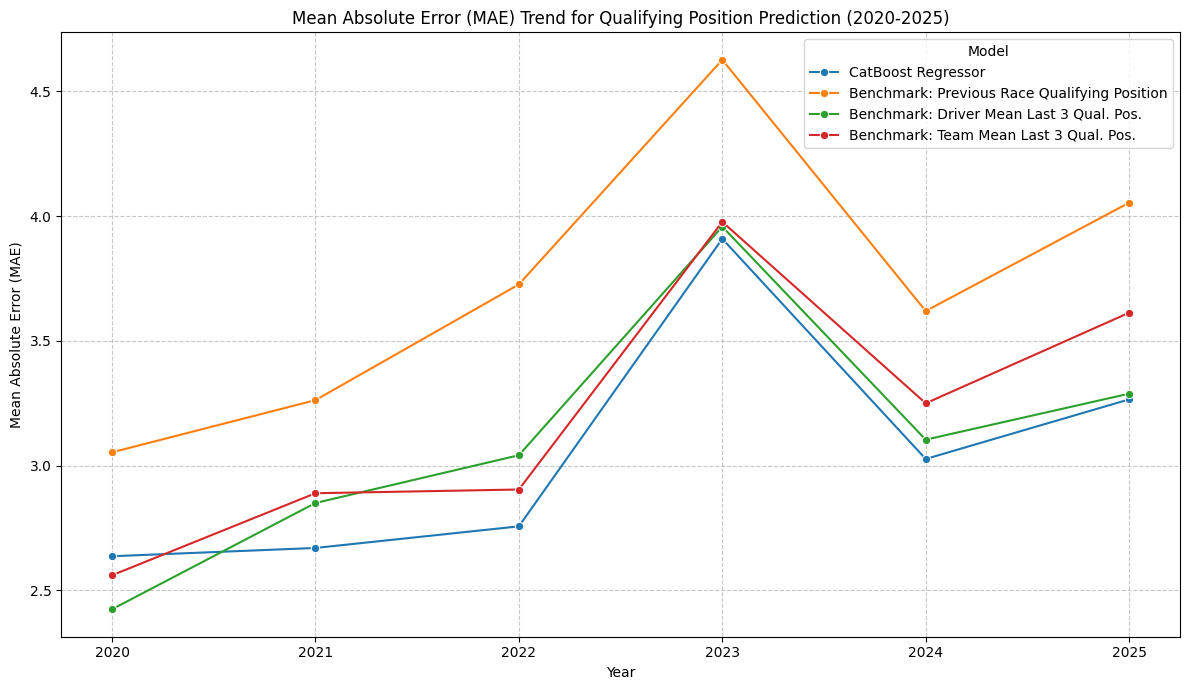

In [87]:
fig = plt.figure(figsize=(12, 7))
sns.lineplot(data=yearly_mae_df, x='Year', y='MAE', hue='Model', marker='o')
plt.title('Mean Absolute Error (MAE) Trend for Qualifying Position Prediction (2020-2025)')
plt.xlabel('Year')
plt.ylabel('Mean Absolute Error (MAE)')
plt.xticks(yearly_mae_df['Year'].unique())
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Model')
plt.tight_layout()
plt.show()

### Model Recommendation based on Overall MAE

Based on the overall Mean Absolute Error across all prediction years (2020-2025), let's identify the best performing approach among the CatBoost model and the benchmarks.

In [88]:
# The 'results_df' already contains the overall MAE for all models/benchmarks
# for the entire prediction period (2020-2025).

print("Overall MAE across all prediction years (2020-2025):")
display(results_df.sort_values(by='MAE').round(3))

# Implement the decision rule based on overall MAE
best_overall_model_eval = results_df.sort_values(by='MAE').iloc[0]

print(f"\nBased on the overall MAE, the best performing approach is: {best_overall_model_eval['Model']} with an overall MAE of {best_overall_model_eval['MAE']:.3f}.")
print("This aligns with the decision rule as it generates the most credible expectations (lowest MAE) over the entire prediction period.")

Overall MAE across all prediction years (2020-2025):


,Model,MAE,Spearman Correlation,% Within 3 Positions
0,CatBoost Regressor,3.024,0.734,66.633
2,Benchmark: Driver Mean Last 3 Qual. Pos.,3.098,0.718,60.280
3,Benchmark: Team Mean Last 3 Qual. Pos.,3.183,0.699,57.929
1,Benchmark: Previous Race Qualifying Position,3.707,0.623,58.329



Based on the overall MAE, the best performing approach is: CatBoost Regressor with an overall MAE of 3.024.
This aligns with the decision rule as it generates the most credible expectations (lowest MAE) over the entire prediction period.


### Decision Rule

*   **If CatBoost clearly beats the simple benchmarks**, use CatBoost expectations.
*   **If it performs similarly**, use the simpler rolling benchmark.
*   **If it performs worse**, do not use it as the reference point.

A more complex model is only justified when it generates more credible expectations.

In [89]:
df_merged_clean.columns

Index(['season', 'round', 'DriverId', 'TeamId', 'grid_position',
       'race_finishing_position', 'classified_position', 'status',
       'raw_points', 'laps_completed', 'event_name', 'location', 'event_date',
       'event_format', 'qualifying_position', 'Q1', 'Q2', 'Q3',
       'classification_points', 'Top10', 'Podium', 'IncidentDNF',
       'driver_points_mean_last3', 'driver_qualifying_mean_last3',
       'driver_incident_rate_last10', 'driver_previous_starts',
       'mean_team_classification_points_per_race',
       'mean_team_qualifying_position_per_race', 'team_points_mean_last3',
       'team_qualifying_mean_last3',
       'driver_season_to_date_qualifying_average',
       'team_season_to_date_qualifying_average',
       'previous_qualifying_position'],
      dtype='object')

### Merging Predictions into the Dataset

Now, we'll merge the `predicted_qualifying_score` and `predicted_qualifying_position` from our `final_predictions_df` back into a new DataFrame, `df_with_pred_qualifying`, based on the original `df_merged_clean`. This will allow us to have all the data, including the model's predictions, in one place for further analysis.

NOTE: Remember that because we trained it with 2018 and 2019 you should not expect to see predictions for it. Still we need to understand why it wouldn't for some.

In [90]:
# Create a copy of df_merged_clean to preserve the original
df_with_pred_qualifying = df_merged_clean.copy()

# Merge the predicted qualifying scores and positions from final_predictions_df
# We will left merge to keep all rows from df_with_pred_qualifying and add predictions where available
df_with_pred_qualifying = pd.merge(
    df_with_pred_qualifying,
    final_predictions_df[['season', 'round', 'DriverId', 'TeamId', 'predicted_qualifying_score', 'predicted_qualifying_position']],
    on=['season', 'round', 'DriverId', 'TeamId'],
    how='left'
)

print(f"Shape of df_with_pred_qualifying: {df_with_pred_qualifying.shape}")
print("Columns added: 'predicted_qualifying_score', 'predicted_qualifying_position'")
display(df_with_pred_qualifying.head(5))

Shape of df_with_pred_qualifying: (2970, 35)
Columns added: 'predicted_qualifying_score', 'predicted_qualifying_position'


,season,round,DriverId,TeamId,grid_position,race_finishing_position,classified_position,status,raw_points,laps_completed,...,driver_previous_starts,mean_team_classification_points_per_race,mean_team_qualifying_position_per_race,team_points_mean_last3,team_qualifying_mean_last3,driver_season_to_date_qualifying_average,team_season_to_date_qualifying_average,previous_qualifying_position,predicted_qualifying_score,predicted_qualifying_position
0,2020,16,aitken,williams,17,16,16,Finished,0.0,87,...,NaN,0.0,17.5,0.000000,17.333333,NaN,17.166667,<NA>,NaN,NaN
1,2019,1,albon,toro_rosso,13,14,14,+1 Lap,0.0,57,...,NaN,0.5,14.0,0.166667,14.833333,NaN,NaN,<NA>,NaN,NaN
2,2019,2,albon,toro_rosso,12,9,9,Finished,2.0,57,...,1.0,1.0,13.5,0.166667,14.666667,13.000000,14.000000,13,NaN,NaN
3,2019,4,albon,toro_rosso,11,11,11,+1 Lap,0.0,50,...,2.0,0.0,9.0,0.500000,12.833333,12.500000,12.833333,12,NaN,NaN
4,2019,5,albon,toro_rosso,11,11,11,Finished,0.0,66,...,3.0,1.0,10.5,0.333333,11.166667,12.333333,11.875000,12,NaN,NaN


### Engineering Qualifying Surprise Features

We will now engineer the `QualifyingSurprise` feature, defined as `ExpectedQualifyingPosition - ActualQualifyingPosition`. This captures how well a driver performed relative to their prediction. A positive value means they qualified better than expected, and a negative value means they qualified worse.

To allow for asymmetric effects, we will split `QualifyingSurprise` into two separate variables:
-   **`PositiveQualifyingSurprise`**: `max(QualifyingSurprise, 0)` – captures only instances where a driver exceeded expectations.
-   **`NegativeQualifyingSurprise`**: `max(-QualifyingSurprise, 0)` – captures only instances where a driver underperformed expectations.

In [91]:
# Calculate QualifyingSurprise
df_with_pred_qualifying['QualifyingSurprise'] = df_with_pred_qualifying['predicted_qualifying_position'] - df_with_pred_qualifying['qualifying_position']

# Split into PositiveQualifyingSurprise and NegativeQualifyingSurprise
df_with_pred_qualifying['PositiveQualifyingSurprise'] = df_with_pred_qualifying['QualifyingSurprise'].apply(lambda x: max(x, 0))
df_with_pred_qualifying['NegativeQualifyingSurprise'] = df_with_pred_qualifying['QualifyingSurprise'].apply(lambda x: max(-x, 0))

print("Engineered QualifyingSurprise features:")
display(df_with_pred_qualifying[['season', 'round', 'DriverId', 'qualifying_position', 'predicted_qualifying_position', 'QualifyingSurprise', 'PositiveQualifyingSurprise', 'NegativeQualifyingSurprise']].tail(30))

Engineered QualifyingSurprise features:


,season,round,DriverId,qualifying_position,predicted_qualifying_position,QualifyingSurprise,PositiveQualifyingSurprise,NegativeQualifyingSurprise
2940,2023,6,zhou,19,15.0,-4.0,0.0,4.0
2941,2023,7,zhou,13,19.0,6.0,6.0,0.0
2942,2023,8,zhou,20,19.0,-1.0,0.0,1.0
2943,2023,10,zhou,17,19.0,2.0,2.0,0.0
2944,2023,11,zhou,5,18.0,13.0,13.0,0.0
2945,2023,13,zhou,16,17.0,1.0,1.0,0.0
2946,2023,14,zhou,16,16.0,0.0,0.0,-0.0
2947,2023,15,zhou,19,17.0,-2.0,0.0,2.0
2948,2023,16,zhou,19,20.0,1.0,1.0,0.0
2949,2023,19,zhou,10,20.0,10.0,10.0,0.0


### Expected Points Model: Data Preparation

This is the second auxiliary model, aiming to estimate the `classification_points` each driver was expected to score before a Grand Prix. We will select features based on conventional pre-race information and explicitly exclude any information that might incorporate behavioral variables we want to test later (e.g., `QualifyingSurprise`).

In [92]:
# Define target and features for the Expected Points model
TARGET_POINTS = 'classification_points'
FEATURES_POINTS = [
    'qualifying_position',
    'driver_points_mean_last3',
    'team_points_mean_last3',
    'driver_qualifying_mean_last3',
    'team_qualifying_mean_last3',
    'driver_incident_rate_last10',
    'driver_previous_starts',
    'DriverId',
    'TeamId',
    'location',
    'season',
    'round'
]

# Create a DataFrame for the points model, dropping rows with NaN in target or features
df_model_points = df_merged_clean[FEATURES_POINTS + [TARGET_POINTS]].dropna(subset=FEATURES_POINTS + [TARGET_POINTS])

# Identify categorical features for CatBoost (same as before, plus qualifying_position which can be treated as ordinal or categorical)
CATEGORICAL_FEATURES_POINTS = [
    'DriverId',
    'TeamId',
    'location',
    'qualifying_position' # Including qualifying position as a categorical feature
]

print(f"Shape of data for expected points model: {df_model_points.shape}")
display(df_model_points.head())

Shape of data for expected points model: (2916, 13)


,qualifying_position,driver_points_mean_last3,team_points_mean_last3,driver_qualifying_mean_last3,team_qualifying_mean_last3,driver_incident_rate_last10,driver_previous_starts,DriverId,TeamId,location,season,round,classification_points
2,12,0.000000,0.166667,13.000000,14.666667,0.0,1.0,albon,toro_rosso,Sakhir,2019,2,2
3,12,1.000000,0.500000,12.500000,12.833333,0.0,2.0,albon,toro_rosso,Baku,2019,4,0
4,12,0.666667,0.333333,12.333333,11.166667,0.0,3.0,albon,toro_rosso,Barcelona,2019,5,0
5,10,0.666667,0.333333,12.000000,10.166667,0.0,4.0,albon,toro_rosso,Monte Carlo,2019,6,4
6,14,1.333333,2.000000,11.333333,9.500000,0.0,5.0,albon,toro_rosso,Montréal,2019,7,0


### Expected Points Model: Walk-Forward Prediction

We will apply the same walk-forward prediction strategy as for the qualifying model. For each race, the model will be trained on all historical data up to that race (excluding the current race's outcome), predict the expected `classification_points`, and then add the actual outcome to the historical data for the next iteration.

The `CatBoostRegressor` will use `RMSE` (Root Mean Squared Error) as the loss function, as we are predicting a continuous value (points).

Finally, predicted points will be constrained to `min(25, max(0, PredictedPoints))` to reflect the actual possible range of points.

In [93]:
from catboost import CatBoostRegressor, Pool
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Prepare lists to store points predictions
all_points_predictions = []

# Define the years for training, validation, and walk-forward prediction
# TRAIN_YEAR and VALID_YEAR are already defined from the qualifying model setup
# PREDICT_START_YEAR is also defined

print(f"\nStarting walk-forward prediction for expected points from {PREDICT_START_YEAR} onward...")

# Get unique season-round combinations to iterate through chronologically
# Use the race_schedule from df_model_qualifying as it covers all races.
race_schedule_points = df_model_points[['season', 'round']].drop_duplicates().sort_values(by=['season', 'round'])

# Initialize a DataFrame to store all historical training data dynamically for points model
historical_data_points = df_model_points[df_model_points['season'] < PREDICT_START_YEAR].copy()

for current_season, current_round in race_schedule_points[race_schedule_points['season'] >= PREDICT_START_YEAR].itertuples(index=False):
    print(f"Processing: Season {current_season}, Round {current_round}")

    # 1. Use all classification observations from earlier races (historical_data_points)
    X_train_points_walk = historical_data_points[FEATURES_POINTS]
    Y_train_points_walk = historical_data_points[TARGET_POINTS]

    # Get current race data (drivers for whom we need to predict)
    current_race_df_points = df_model_points[
        (df_model_points['season'] == current_season) &
        (df_model_points['round'] == current_round)
    ].copy()

    if current_race_df_points.empty or X_train_points_walk.empty:
        print(f"No data for Season {current_season}, Round {current_round} or empty training data. Skipping.")
        # Add an empty prediction record to maintain structure if skipped
        skipped_df = pd.DataFrame({
            'season': [current_season] * len(current_race_df_points),
            'round': [current_round] * len(current_race_df_points),
            'DriverId': current_race_df_points['DriverId'],
            'TeamId': current_race_df_points['TeamId'],
            'classification_points': current_race_df_points[TARGET_POINTS],
            'predicted_classification_points': np.nan, # No discrete prediction
            'predicted_classification_points_raw': np.nan # No raw prediction
        })
        all_points_predictions.append(skipped_df)
        # Ensure to add to historical data only if actual data exists
        historical_data_points = pd.concat([historical_data_points, current_race_df_points[FEATURES_POINTS + [TARGET_POINTS]]], ignore_index=True)
        continue

    X_predict_points = current_race_df_points[FEATURES_POINTS]

    # 2. Fit the points model
    current_points_model = CatBoostRegressor(
        iterations=200, # Initial iterations, will rely on early stopping if validation set is used
        loss_function='RMSE', # Use RMSE for point prediction
        eval_metric='MAE', # Monitor MAE during training
        random_seed=42,
        verbose=False,
        cat_features=CATEGORICAL_FEATURES_POINTS
    )
    current_points_model.fit(X_train_points_walk, Y_train_points_walk)

    # 3. Predict expected classification points for the current race
    current_race_points_preds = current_points_model.predict(X_predict_points)

    # Apply constraint: ExpectedPoints = min(25, max(0, PredictedPoints))
    current_race_points_preds_constrained = np.clip(current_race_points_preds, 0, 25)

    # Rename the continuous predictions as requested
    current_race_df_points['predicted_classification_points_raw'] = current_race_points_preds_constrained

    # --- Convert raw predicted scores to discrete classification points for the current race ---
    # This must be done *per race*, as points are awarded based on rank within a single race.

    # Sort by raw predicted points in descending order to assign ranks
    # Reset index to get 0-indexed positions, then add 1 for 1-indexed ranks
    current_race_df_points_ranked = current_race_df_points.sort_values(
        by='predicted_classification_points_raw', ascending=False
    ).reset_index(drop=True)

    # Assign ranks (1-indexed)
    current_race_df_points_ranked['predicted_rank'] = current_race_df_points_ranked.index + 1

    # Map ranks to classification points
    point_mapping = {
        1: 25, 2: 18, 3: 15, 4: 12, 5: 10,
        6: 8, 7: 6, 8: 4, 9: 2, 10: 1
    }
    current_race_df_points_ranked['predicted_classification_points'] = current_race_df_points_ranked['predicted_rank'].apply(
        lambda x: point_mapping.get(x, 0) # Default to 0 for ranks > 10
    )

    # Merge the calculated discrete points back to the original structure for the current race
    current_race_df_points = pd.merge(
        current_race_df_points,
        current_race_df_points_ranked[['DriverId', 'TeamId', 'predicted_classification_points']],
        on=['DriverId', 'TeamId'],
        how='left'
    )

    # Store predictions for analysis (include both raw and discrete predicted points)
    all_points_predictions.append(
        current_race_df_points[['season', 'round', 'DriverId', 'TeamId', TARGET_POINTS, 'predicted_classification_points', 'predicted_classification_points_raw']]
    )

    # 6. Add the completed race to the historical dataset.
    historical_data_points = pd.concat([historical_data_points, current_race_df_points[FEATURES_POINTS + [TARGET_POINTS]]], ignore_index=True)

# Concatenate all points predictions into a single DataFrame
final_points_predictions_df = pd.concat(all_points_predictions, ignore_index=True)

print("\nExpected points model built and predictions generated.")
print("First 10 points predictions:")
display(final_points_predictions_df.head(10))


Starting walk-forward prediction for expected points from 2020 onward...
Processing: Season 2020, Round 1
Processing: Season 2020, Round 2
Processing: Season 2020, Round 3
Processing: Season 2020, Round 4
Processing: Season 2020, Round 5
Processing: Season 2020, Round 6
Processing: Season 2020, Round 7
Processing: Season 2020, Round 8
Processing: Season 2020, Round 9
Processing: Season 2020, Round 10
Processing: Season 2020, Round 11
Processing: Season 2020, Round 12
Processing: Season 2020, Round 13
Processing: Season 2020, Round 14
Processing: Season 2020, Round 15
Processing: Season 2020, Round 16
Processing: Season 2020, Round 17
Processing: Season 2021, Round 1
Processing: Season 2021, Round 2
Processing: Season 2021, Round 3
Processing: Season 2021, Round 4
Processing: Season 2021, Round 5
Processing: Season 2021, Round 6
Processing: Season 2021, Round 7
Processing: Season 2021, Round 8
Processing: Season 2021, Round 9
Processing: Season 2021, Round 11
Processing: Season 2021, R

,season,round,DriverId,TeamId,classification_points,predicted_classification_points,predicted_classification_points_raw
0,2020,1,albon,red_bull,0,12,9.338187
1,2020,1,bottas,mercedes,25,18,14.231903
2,2020,1,giovinazzi,alfa,2,0,0.606542
3,2020,1,grosjean,haas,0,0,0.000000
4,2020,1,hamilton,mercedes,12,25,16.530355
5,2020,1,kevin_magnussen,haas,0,0,0.000000
6,2020,1,leclerc,ferrari,18,10,8.583473
7,2020,1,max_verstappen,red_bull,0,15,13.923981
8,2020,1,norris,mclaren,15,6,7.156103
9,2020,1,ocon,renault,4,0,0.936021


### Expected Points Model Evaluation: CatBoost vs. Simple Benchmarks

Now, let's evaluate the performance of our CatBoost Expected Points Model against several benchmarks:

1.  **CatBoost Regressor (Raw)**: The continuous point predictions from our model.
2.  **CatBoost Regressor (Discrete)**: The discrete F1 points derived from ranking the raw predictions.
3.  **Benchmark: Previous Race Points**: Points scored by the driver in the immediately preceding race.
4.  **Benchmark: Driver Mean Points Last 3 Races**: Average points scored by the driver over their last 3 races.
5.  **Benchmark: Team Mean Points Last 3 Races**: Average points scored by the team (per car) over their last 3 races.
6.  **Benchmark: Average Points by Qualifying Position**: The historical average classification points for a given qualifying position.

We will evaluate each model/benchmark based on:

*   Mean Absolute Error (MAE)
*   Root Mean Squared Error (RMSE)

In [94]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Start with df_model_points and filter for prediction years
df_points_eval_base = df_model_points[df_model_points['season'] >= PREDICT_START_YEAR].copy()

# Merge with final_points_predictions_df to add the predictions
df_points_eval = pd.merge(
    df_points_eval_base,
    final_points_predictions_df[['season', 'round', 'DriverId', 'TeamId', 'predicted_classification_points', 'predicted_classification_points_raw']],
    on=['season', 'round', 'DriverId', 'TeamId'],
    how='left'
)

# Calculate 'previous_classification_points' for each driver
# This needs to be done on the full df_merged_clean to ensure correct chronological order
df_merged_clean_sorted = df_merged_clean.sort_values(by=['DriverId', 'season', 'round'])
df_merged_clean_sorted['previous_classification_points_calc'] = df_merged_clean_sorted.groupby('DriverId')['classification_points'].shift(1)

# Merge this into df_points_eval
df_points_eval = pd.merge(
    df_points_eval,
    df_merged_clean_sorted[['season', 'round', 'DriverId', 'TeamId', 'previous_classification_points_calc']],
    on=['season', 'round', 'DriverId', 'TeamId'],
    how='left'
)
df_points_eval['previous_classification_points'] = df_points_eval['previous_classification_points_calc'].fillna(0) # Fill NaN with 0 for drivers' first race
df_points_eval.drop(columns=['previous_classification_points_calc'], inplace=True)

# Calculate 'avg_points_by_qualifying_position'
# Calculate this based on all historical data available before the prediction start year
historical_points_for_avg = df_model_points[df_model_points['season'] < PREDICT_START_YEAR]
avg_points_by_qual_pos = historical_points_for_avg.groupby('qualifying_position')['classification_points'].mean().reset_index()
avg_points_by_qual_pos.rename(columns={'classification_points': 'avg_points_for_qual_pos'}, inplace=True)

# Merge this into df_points_eval
df_points_eval = pd.merge(
    df_points_eval,
    avg_points_by_qual_pos,
    on='qualifying_position',
    how='left'
)
df_points_eval['avg_points_for_qual_pos'] = df_points_eval['avg_points_for_qual_pos'].fillna(0) # Fill NaN for new qual_pos or positions not seen in historical data

# Drop rows where actual target or critical predictions/benchmarks are NaN
df_points_eval.dropna(subset=[
    'classification_points',
    'predicted_classification_points_raw',
    'predicted_classification_points',
    'driver_points_mean_last3',
    'team_points_mean_last3',
    'previous_classification_points',
    'avg_points_for_qual_pos'
], inplace=True)

print(f"Shape of df_points_eval: {df_points_eval.shape}")
display(df_points_eval.head())

def evaluate_points_model(y_true, y_pred, model_name):
    """Calculates MAE and RMSE for points prediction."""
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return {
        'Model': model_name,
        'MAE': mae,
        'RMSE': rmse
    }

# Overall Evaluation
points_results = []

# CatBoost Regressor (Raw Predictions)
points_results.append(evaluate_points_model(
    df_points_eval['classification_points'],
    df_points_eval['predicted_classification_points_raw'],
    'CatBoost Regressor (Raw)'
))

# CatBoost Regressor (Discrete F1 Points)
points_results.append(evaluate_points_model(
    df_points_eval['classification_points'],
    df_points_eval['predicted_classification_points'],
    'CatBoost Regressor (Discrete)'
))

# Benchmark: Previous Race Points
points_results.append(evaluate_points_model(
    df_points_eval['classification_points'],
    df_points_eval['previous_classification_points'],
    'Benchmark: Previous Race Points'
))

# Benchmark: Driver Mean Points Last 3 Races
points_results.append(evaluate_points_model(
    df_points_eval['classification_points'],
    df_points_eval['driver_points_mean_last3'],
    'Benchmark: Driver Mean Last 3 Pts.'
))

# Benchmark: Team Mean Points Last 3 Races
points_results.append(evaluate_points_model(
    df_points_eval['classification_points'],
    df_points_eval['team_points_mean_last3'],
    'Benchmark: Team Mean Last 3 Pts.'
))

# Benchmark: Average Points by Qualifying Position
points_results.append(evaluate_points_model(
    df_points_eval['classification_points'],
    df_points_eval['avg_points_for_qual_pos'],
    'Benchmark: Avg Pts by Qual. Pos.'
))

points_results_df = pd.DataFrame(points_results)

print("\nOverall MAE and RMSE across all prediction years (2020-2025) for Expected Points Model:")
display(points_results_df.sort_values(by='MAE').round(3))

Shape of df_points_eval: (2107, 17)


,qualifying_position,driver_points_mean_last3,team_points_mean_last3,driver_qualifying_mean_last3,team_qualifying_mean_last3,driver_incident_rate_last10,driver_previous_starts,DriverId,TeamId,location,season,round,classification_points,predicted_classification_points,predicted_classification_points_raw,previous_classification_points,avg_points_for_qual_pos
0,5,6.000000,12.666667,6.000000,4.166667,0.0,20.0,albon,red_bull,Spielberg,2020,1,0,12,9.338187,8.0,8.024390
1,7,2.666667,8.500000,5.666667,4.000000,0.0,21.0,albon,red_bull,Spielberg,2020,2,12,6,7.144563,0.0,4.609756
2,13,6.666667,8.833333,6.000000,4.333333,0.0,22.0,albon,red_bull,Budapest,2020,3,10,4,6.710330,12.0,1.725000
3,12,7.333333,9.166667,8.333333,6.166667,0.0,23.0,albon,red_bull,Silverstone,2020,4,4,6,6.166635,10.0,1.756098
4,9,8.666667,12.833333,10.666667,7.333333,0.0,24.0,albon,red_bull,Silverstone,2020,5,10,8,5.156456,4.0,3.075000



Overall MAE and RMSE across all prediction years (2020-2025) for Expected Points Model:


,Model,MAE,RMSE
1,CatBoost Regressor (Discrete),2.864,5.099
0,CatBoost Regressor (Raw),3.019,4.660
5,Benchmark: Avg Pts by Qual. Pos.,3.169,4.769
3,Benchmark: Driver Mean Last 3 Pts.,3.505,5.427
4,Benchmark: Team Mean Last 3 Pts.,3.630,5.463
2,Benchmark: Previous Race Points,3.956,6.464


### Yearly Walk-Forward MAE and RMSE Trend Analysis for Expected Points

Now, let's analyze the performance of the CatBoost Expected Points model and the benchmarks for each prediction year (2020-2025) individually. We will calculate the MAE and RMSE for each year and visualize the trend.

In [95]:
import matplotlib.pyplot as plt
import seaborn as sns

yearly_points_results = []

for year in range(PREDICT_START_YEAR, 2026): # Assuming prediction years go up to 2025
    df_year_points = df_points_eval[df_points_eval['season'] == year]

    if df_year_points.empty:
        print(f"No data for points evaluation for year {year}. Skipping.")
        continue

    # CatBoost Regressor (Raw)
    yearly_points_results.append({
        'Year': year,
        'Model': 'CatBoost Regressor (Raw)',
        'MAE': evaluate_points_model(
            df_year_points['classification_points'],
            df_year_points['predicted_classification_points_raw'],
            'CatBoost Regressor (Raw)'
        )['MAE'],
        'RMSE': evaluate_points_model(
            df_year_points['classification_points'],
            df_year_points['predicted_classification_points_raw'],
            'CatBoost Regressor (Raw)'
        )['RMSE']
    })
    # CatBoost Regressor (Discrete)
    yearly_points_results.append({
        'Year': year,
        'Model': 'CatBoost Regressor (Discrete)',
        'MAE': evaluate_points_model(
            df_year_points['classification_points'],
            df_year_points['predicted_classification_points'],
            'CatBoost Regressor (Discrete)'
        )['MAE'],
        'RMSE': evaluate_points_model(
            df_year_points['classification_points'],
            df_year_points['predicted_classification_points'],
            'CatBoost Regressor (Discrete)'
        )['RMSE']
    })
    # Benchmark: Previous Race Points
    yearly_points_results.append({
        'Year': year,
        'Model': 'Benchmark: Previous Race Points',
        'MAE': evaluate_points_model(
            df_year_points['classification_points'],
            df_year_points['previous_classification_points'],
            'Benchmark: Previous Race Points'
        )['MAE'],
        'RMSE': evaluate_points_model(
            df_year_points['classification_points'],
            df_year_points['previous_classification_points'],
            'Benchmark: Previous Race Points'
        )['RMSE']
    })
    # Benchmark: Driver Mean Last 3 Pts.
    yearly_points_results.append({
        'Year': year,
        'Model': 'Benchmark: Driver Mean Last 3 Pts.',
        'MAE': evaluate_points_model(
            df_year_points['classification_points'],
            df_year_points['driver_points_mean_last3'],
            'Benchmark: Driver Mean Last 3 Pts.'
        )['MAE'],
        'RMSE': evaluate_points_model(
            df_year_points['classification_points'],
            df_year_points['driver_points_mean_last3'],
            'Benchmark: Driver Mean Last 3 Pts.'
        )['RMSE']
    })
    # Benchmark: Team Mean Last 3 Pts.
    yearly_points_results.append({
        'Year': year,
        'Model': 'Benchmark: Team Mean Last 3 Pts.',
        'MAE': evaluate_points_model(
            df_year_points['classification_points'],
            df_year_points['team_points_mean_last3'],
            'Benchmark: Team Mean Last 3 Pts.'
        )['MAE'],
        'RMSE': evaluate_points_model(
            df_year_points['classification_points'],
            df_year_points['team_points_mean_last3'],
            'Benchmark: Team Mean Last 3 Pts.'
        )['RMSE']
    })
    # Benchmark: Avg Pts by Qual. Pos.
    yearly_points_results.append({
        'Year': year,
        'Model': 'Benchmark: Avg Pts by Qual. Pos.',
        'MAE': evaluate_points_model(
            df_year_points['classification_points'],
            df_year_points['avg_points_for_qual_pos'],
            'Benchmark: Avg Pts by Qual. Pos.'
        )['MAE'],
        'RMSE': evaluate_points_model(
            df_year_points['classification_points'],
            df_year_points['avg_points_for_qual_pos'],
            'Benchmark: Avg Pts by Qual. Pos.'
        )['RMSE']
    })

yearly_points_results_df = pd.DataFrame(yearly_points_results)

print("Yearly MAE and RMSE results for Expected Points:")
display(yearly_points_results_df.round(3))

Yearly MAE and RMSE results for Expected Points:


,Year,Model,MAE,RMSE
0,2020,CatBoost Regressor (Raw),3.783,5.434
1,2020,CatBoost Regressor (Discrete),3.761,6.173
2,2020,Benchmark: Previous Race Points,4.484,7.298
3,2020,Benchmark: Driver Mean Last 3 Pts.,3.921,5.875
4,2020,Benchmark: Team Mean Last 3 Pts.,4.042,5.833
5,2020,Benchmark: Avg Pts by Qual. Pos.,3.587,5.377
6,2021,CatBoost Regressor (Raw),3.334,5.119
7,2021,CatBoost Regressor (Discrete),3.153,5.636
8,2021,Benchmark: Previous Race Points,4.156,6.672
9,2021,Benchmark: Driver Mean Last 3 Pts.,3.847,5.770


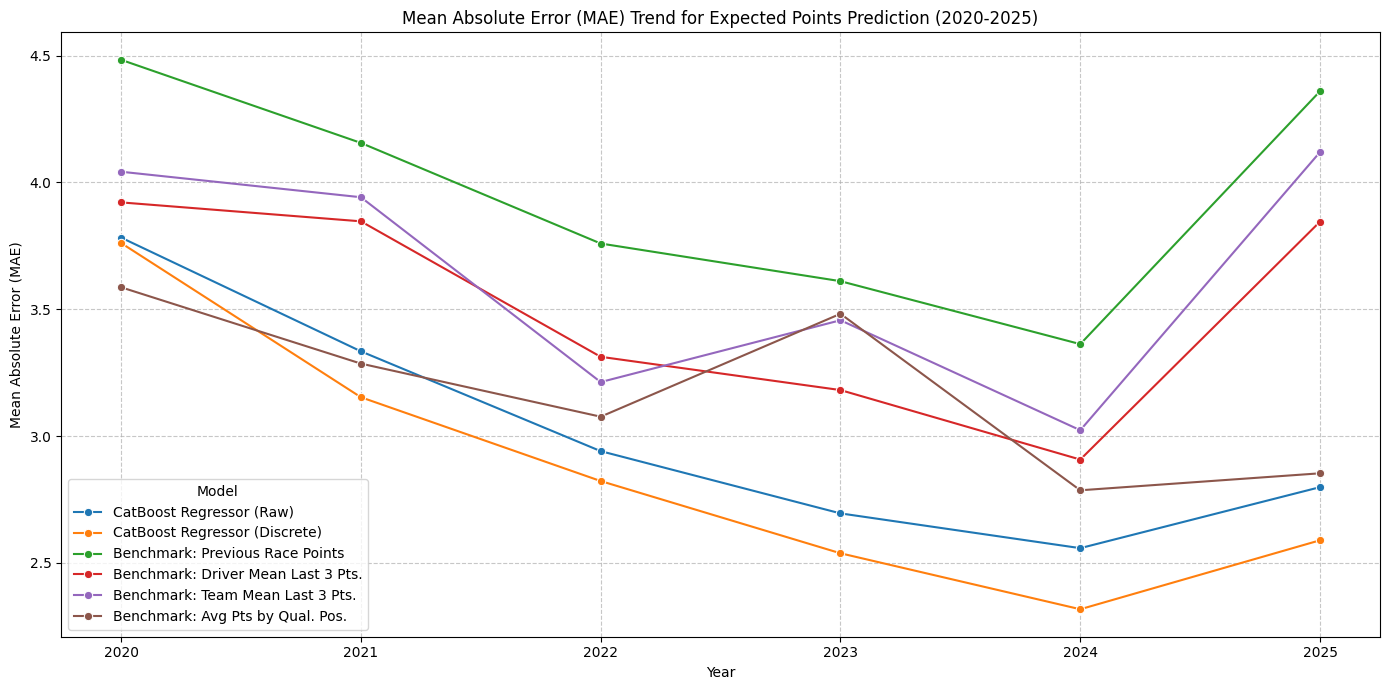

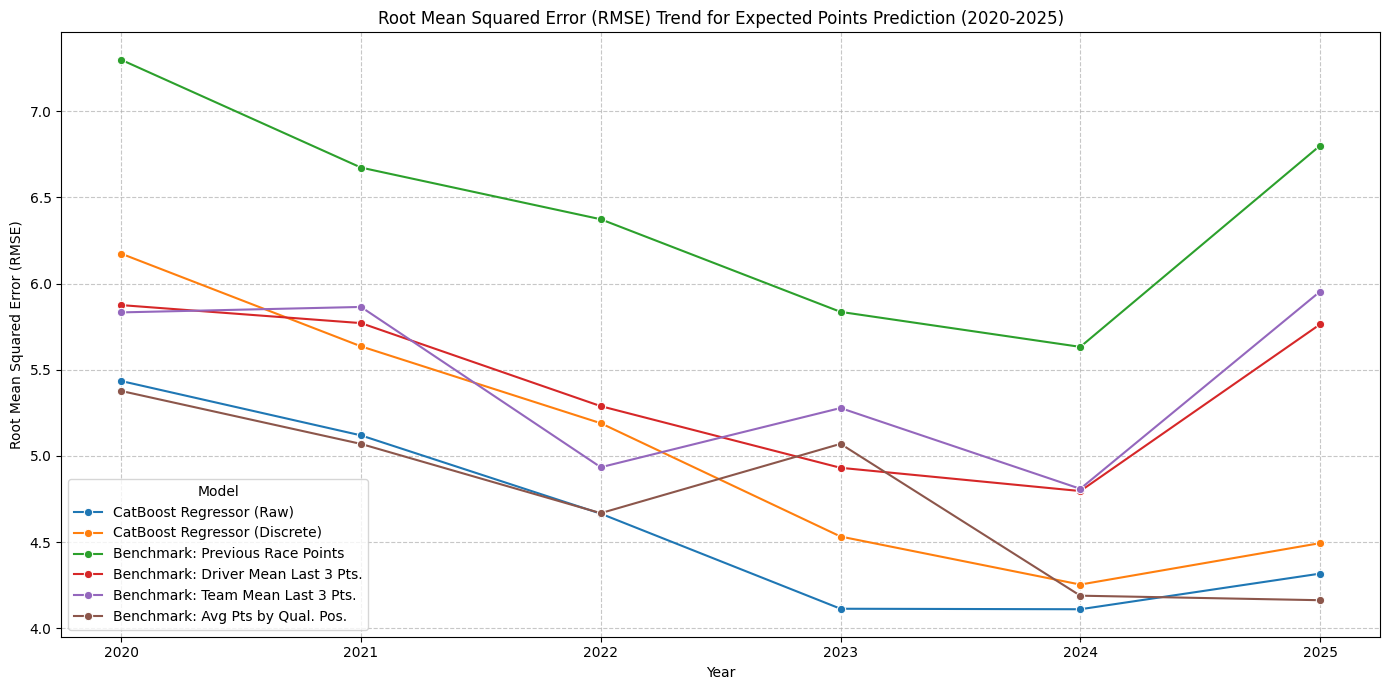

In [96]:
fig_mae = plt.figure(figsize=(14, 7))
sns.lineplot(data=yearly_points_results_df, x='Year', y='MAE', hue='Model', marker='o')
plt.title('Mean Absolute Error (MAE) Trend for Expected Points Prediction (2020-2025)')
plt.xlabel('Year')
plt.ylabel('Mean Absolute Error (MAE)')
plt.xticks(yearly_points_results_df['Year'].unique())
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Model')
plt.tight_layout()
plt.show()

fig_rmse = plt.figure(figsize=(14, 7))
sns.lineplot(data=yearly_points_results_df, x='Year', y='RMSE', hue='Model', marker='o')
plt.title('Root Mean Squared Error (RMSE) Trend for Expected Points Prediction (2020-2025)')
plt.xlabel('Year')
plt.ylabel('Root Mean Squared Error (RMSE)')
plt.xticks(yearly_points_results_df['Year'].unique())
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Model')
plt.tight_layout()
plt.show()

### Model Recommendation based on Overall MAE/RMSE for Expected Points

Based on the overall Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE) across all prediction years (2020-2025), let's identify the best performing approach among the CatBoost model and the benchmarks.

**Decision Rule:**

*   **If CatBoost clearly beats the simple benchmarks**, use CatBoost expectations.
*   **If it performs similarly**, consider the simpler rolling benchmark.
*   **If it performs worse**, do not use it as the reference point.

A more complex model is only justified when it generates more credible expectations.

In [97]:
print("Overall MAE and RMSE across all prediction years (2020-2025) for Expected Points Model:")
display(points_results_df.sort_values(by='MAE').round(3))

# Determine the best model based on overall MAE
best_overall_points_model_mae = points_results_df.sort_values(by='MAE').iloc[0]

print(f"\nBased on the overall MAE, the best performing approach for expected points is: {best_overall_points_model_mae['Model']} with an overall MAE of {best_overall_points_model_mae['MAE']:.3f}.")

print("\n### Mean Predicted and Actual Points & Actual Average Points within Predicted-Points Groups\n")

# Calculate overall mean predicted and actual points
mean_predicted_raw = df_points_eval['predicted_classification_points_raw'].mean()
mean_predicted_discrete = df_points_eval['predicted_classification_points'].mean()
mean_actual = df_points_eval['classification_points'].mean()

print(f"Overall Mean Predicted (Raw) Classification Points: {mean_predicted_raw:.2f}")
print(f"Overall Mean Predicted (Discrete) Classification Points: {mean_predicted_discrete:.2f}")
print(f"Overall Mean Actual Classification Points: {mean_actual:.2f}\n")

# Define interval tuples for predicted points groups based on the raw scores
# Example: '0' means predicted raw score is exactly 0. '0-2' means (0, 2] etc.
intervals = [
    pd.Interval(-0.1, 0.001, closed='right'), # For actual 0 points (or very close to it)
    pd.Interval(0.001, 2, closed='right'),    # (0, 2] exclusive of 0, inclusive of 2
    pd.Interval(2, 5, closed='right'),        # (2, 5]
    pd.Interval(5, 10, closed='right'),       # (5, 10]
    pd.Interval(10, 15, closed='right'),      # (10, 15]
    pd.Interval(15, df_points_eval['predicted_classification_points_raw'].max() + 1, closed='right') # (15, max]
]
labels = ['0', '0-2', '2-5', '5-10', '10-15', '>15']

df_points_eval['predicted_points_group'] = pd.cut(
    df_points_eval['predicted_classification_points_raw'],
    bins=intervals,
    labels=labels
)

# Calculate actual average points within these groups
avg_actual_points_by_group = df_points_eval.groupby('predicted_points_group')['classification_points'].mean().reset_index()
avg_actual_points_by_group.rename(columns={'classification_points': 'Actual_Average_Points'}, inplace=True)
print("Actual Average Points within Predicted Raw Points Groups:")
display(avg_actual_points_by_group)

Overall MAE and RMSE across all prediction years (2020-2025) for Expected Points Model:


,Model,MAE,RMSE
1,CatBoost Regressor (Discrete),2.864,5.099
0,CatBoost Regressor (Raw),3.019,4.660
5,Benchmark: Avg Pts by Qual. Pos.,3.169,4.769
3,Benchmark: Driver Mean Last 3 Pts.,3.505,5.427
4,Benchmark: Team Mean Last 3 Pts.,3.630,5.463
2,Benchmark: Previous Race Points,3.956,6.464



Based on the overall MAE, the best performing approach for expected points is: CatBoost Regressor (Discrete) with an overall MAE of 2.864.

### Mean Predicted and Actual Points & Actual Average Points within Predicted-Points Groups

Overall Mean Predicted (Raw) Classification Points: 5.11
Overall Mean Predicted (Discrete) Classification Points: 5.13
Overall Mean Actual Classification Points: 5.11

Actual Average Points within Predicted Raw Points Groups:


/tmp/ipykernel_1513/3629401441.py:39: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_actual_points_by_group = df_points_eval.groupby('predicted_points_group')['classification_points'].mean().reset_index()


,predicted_points_group,Actual_Average_Points
0,"(-0.1, 0.001]",0.335968
1,"(0.001, 2.0]",0.738346
2,"(2.0, 5.0]",3.351421
3,"(5.0, 10.0]",7.466495
4,"(10.0, 15.0]",12.079167
5,"(15.0, 26.0]",17.862069


### Engineering Race Gain and Race Loss Features

We will now engineer two new features to capture a driver's performance during the race relative to their qualifying position:

-   **`RaceGain`**: `qualifying_position - race_finishing_position`. This indicates how many positions a driver gained from their qualifying start to their race finish. A positive value means they gained positions.
-   **`RaceLoss`**: `race_finishing_position - qualifying_position`. This indicates how many positions a driver lost from their qualifying start to their race finish. A positive value means they lost positions.

In [98]:
# Drop columns if they exist from a previous run to ensure an idempotent merge
existing_cols_to_drop = ['predicted_classification_points', 'predicted_classification_points_raw']
df_with_pred_qualifying = df_with_pred_qualifying.drop(columns=[col for col in existing_cols_to_drop if col in df_with_pred_qualifying.columns])

# Ensure predicted classification points are merged into df_with_pred_qualifying
# This merge should happen once, before RaceGain and RaceLoss are calculated.
# We use 'left' join to keep all rows from df_with_pred_qualifying and add predictions where available.
df_with_pred_qualifying = pd.merge(
    df_with_pred_qualifying,
    final_points_predictions_df[['season', 'round', 'DriverId', 'TeamId', 'predicted_classification_points', 'predicted_classification_points_raw']],
    on=['season', 'round', 'DriverId', 'TeamId'],
    how='left'
)

# Fill any potential NaN values in predicted points that might result from the merge
# (e.g., for races before the prediction start year, or if there was no prediction for a specific driver/race)
df_with_pred_qualifying['predicted_classification_points'] = df_with_pred_qualifying['predicted_classification_points'].fillna(0)
df_with_pred_qualifying['predicted_classification_points_raw'] = df_with_pred_qualifying['predicted_classification_points_raw'].fillna(0)

# Calculate RaceGain: how many points a driver gained relative to expected points
df_with_pred_qualifying['RaceGain'] = (df_with_pred_qualifying['classification_points'] - df_with_pred_qualifying['predicted_classification_points']).apply(lambda x: max(x, 0))

# Calculate RaceLoss: how many points a driver lost relative to expected points
df_with_pred_qualifying['RaceLoss'] = (df_with_pred_qualifying['predicted_classification_points'] - df_with_pred_qualifying['classification_points']).apply(lambda x: max(x, 0))

print("Engineered RaceGain and RaceLoss features (point-based):")
display(df_with_pred_qualifying[['season', 'round', 'DriverId', 'classification_points', 'predicted_classification_points', 'RaceGain', 'RaceLoss']].head())

Engineered RaceGain and RaceLoss features (point-based):


,season,round,DriverId,classification_points,predicted_classification_points,RaceGain,RaceLoss
0,2020,16,aitken,0,0.0,0.0,0.0
1,2019,1,albon,0,0.0,0.0,0.0
2,2019,2,albon,2,0.0,2.0,0.0
3,2019,4,albon,0,0.0,0.0,0.0
4,2019,5,albon,0,0.0,0.0,0.0


### Engineering Recent Gain/Loss Exposure Features

Now, we will create features to quantify a driver's recent exposure to gaining or losing positions during races. These rolling sums will provide insights into a driver's performance trends after qualifying.

-   **`RecentGainExposure`**: Rolling sum of `RaceGain` over the last 3 races. This captures how many positions a driver has recently gained in total during races.
-   **`RecentLossExposure`**: Rolling sum of `RaceLoss` over the last 3 races. This captures how many positions a driver has recently lost in total during races.
-   **`exposure_history_count`**: Number of races included in the `RecentGainExposure` and `RecentLossExposure` calculations (up to 3, adjusted for season boundaries and early career).

These features will be calculated while respecting season boundaries, meaning a rolling sum will reset at the start of each new season for a driver.

In [99]:
# To calculate rolling features that respect season boundaries, we'll use a custom aggregation within each driver-season group.

# Sort the DataFrame again by DriverId, season, and round to ensure correct chronological order for rolling calculations
df_with_pred_qualifying.sort_values(by=['DriverId', 'season', 'round'], inplace=True)

# Calculate RecentGainExposure (rolling sum of RaceGain over last 3 races, within each season)
df_with_pred_qualifying['RecentGainExposure'] = df_with_pred_qualifying.groupby(['DriverId', 'season'])['RaceGain'].transform(
    lambda x: x.rolling(window=3, min_periods=1).sum().shift(1)
).fillna(0) # Fill NaN with 0 for first races where no prior exposure exists

# Calculate RecentLossExposure (rolling sum of RaceLoss over last 3 races, within each season)
df_with_pred_qualifying['RecentLossExposure'] = df_with_pred_qualifying.groupby(['DriverId', 'season'])['RaceLoss'].transform(
    lambda x: x.rolling(window=3, min_periods=1).sum().shift(1)
).fillna(0) # Fill NaN with 0 for first races where no prior exposure exists

# Calculate exposure_history_count (number of races contributing to the rolling sum)
df_with_pred_qualifying['exposure_history_count'] = df_with_pred_qualifying.groupby(['DriverId', 'season'])['RaceGain'].transform(
    lambda x: x.rolling(window=3, min_periods=1).count().shift(1)
).fillna(0) # Fill NaN with 0 for first races

print("Engineered RecentGainExposure, RecentLossExposure, and exposure_history_count features:")
display(df_with_pred_qualifying[['season', 'round', 'DriverId', 'qualifying_position', 'race_finishing_position', 'RaceGain', 'RaceLoss', 'RecentGainExposure', 'RecentLossExposure', 'exposure_history_count']].tail(40))

Engineered RecentGainExposure, RecentLossExposure, and exposure_history_count features:


,season,round,DriverId,qualifying_position,race_finishing_position,RaceGain,RaceLoss,RecentGainExposure,RecentLossExposure,exposure_history_count
2930,2022,16,zhou,14,10,1.0,0.0,0.0,0.0,3.0
2931,2022,17,zhou,15,20,0.0,0.0,1.0,0.0,3.0
2932,2022,18,zhou,14,16,0.0,0.0,1.0,0.0,3.0
2933,2022,19,zhou,14,12,0.0,0.0,1.0,0.0,3.0
2934,2022,20,zhou,12,13,0.0,0.0,0.0,0.0,3.0
2935,2022,22,zhou,15,12,0.0,0.0,0.0,0.0,3.0
2936,2023,1,zhou,13,16,0.0,0.0,0.0,0.0,0.0
2937,2023,2,zhou,12,13,0.0,0.0,0.0,0.0,1.0
2938,2023,3,zhou,17,9,2.0,0.0,0.0,0.0,2.0
2939,2023,5,zhou,14,16,0.0,0.0,2.0,0.0,3.0


In [100]:
df_with_pred_qualifying.columns

Index(['season', 'round', 'DriverId', 'TeamId', 'grid_position',
       'race_finishing_position', 'classified_position', 'status',
       'raw_points', 'laps_completed', 'event_name', 'location', 'event_date',
       'event_format', 'qualifying_position', 'Q1', 'Q2', 'Q3',
       'classification_points', 'Top10', 'Podium', 'IncidentDNF',
       'driver_points_mean_last3', 'driver_qualifying_mean_last3',
       'driver_incident_rate_last10', 'driver_previous_starts',
       'mean_team_classification_points_per_race',
       'mean_team_qualifying_position_per_race', 'team_points_mean_last3',
       'team_qualifying_mean_last3',
       'driver_season_to_date_qualifying_average',
       'team_season_to_date_qualifying_average',
       'previous_qualifying_position', 'predicted_qualifying_score',
       'predicted_qualifying_position', 'QualifyingSurprise',
       'PositiveQualifyingSurprise', 'NegativeQualifyingSurprise',
       'predicted_classification_points',
       'predicted_classif

### Download `df_with_pred_qualifying` as CSV

To download the DataFrame to your local machine, run the following cell. It will save the DataFrame as a CSV file and then provide a download link.

In [101]:
from google.colab import files

output_filename = 'df_with_pred_qualifying.csv'
df_with_pred_qualifying.to_csv(output_filename, index=False)

print(f"DataFrame saved to '{output_filename}'. Click the link below to download.")
files.download(output_filename)

DataFrame saved to 'df_with_pred_qualifying.csv'. Click the link below to download.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>